In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## Step 1: Import Required Libraries

The required Python libraries were imported for data handling, visualization, preprocessing, model training, and evaluation.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Step 2: Load the Customer Churn Dataset

The Telco Customer Churn dataset was loaded into a Pandas DataFrame. This dataset will be used to investigate class imbalance and evaluate the impact of balancing techniques on model performance.

In [7]:
print("Churn class counts:")
print(df["Churn"].value_counts())

Churn class counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
print("Churn class percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn class percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


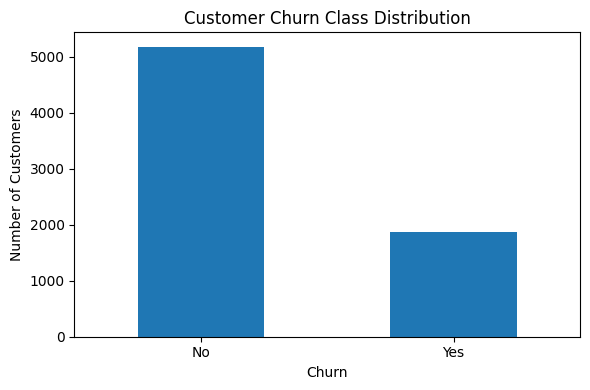

In [9]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Customer Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 3: Check Class Balance

The target variable `Churn` was analyzed to determine the class distribution. The dataset contains 5,174 customers who did not churn (73.46%) and 1,869 customers who churned (26.54%).

This shows that the target variable is imbalanced, with the `No` class representing the majority and the `Yes` class representing the minority. This imbalance may cause a machine learning model to favor the majority class, making accuracy alone an unreliable measure of performance.

In [10]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
# Fill missing TotalCharges values with the median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Verify that there are no missing values
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 0


In [12]:
df = df.drop("customerID", axis=1)

### Step 4: Handling Missing Values and Unnecessary Columns

The `TotalCharges` column contained 11 missing values. These values were replaced with the median of the column. The `customerID` column was removed because it is an identifier and does not provide meaningful predictive information.

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [15]:
X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print(X.head())

Features shape: (7043, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              Fal

## Step 5: Prepare Features and Target

The `Churn` column was selected as the target variable, while the remaining columns were used as input features. The target was converted into binary values, where `0` represents customers who did not churn and `1` represents customers who churned.

Categorical features were converted into numerical dummy variables using one-hot encoding so that they could be used by the Logistic Regression model.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


## Step 6: Split the Dataset

The dataset was divided into training and testing sets using an 80:20 ratio. Stratified splitting was used to maintain a similar proportion of churned and non-churned customers in both sets. The same split will be used for the baseline and balanced models to ensure a fair comparison.

In [17]:
# Train baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# Calculate evaluation metrics
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1-Score:", baseline_f1)

Baseline Precision: 0.6520376175548589
Baseline Recall: 0.5561497326203209
Baseline F1-Score: 0.6002886002886003


In [19]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8034066713981547


## Step 7: Baseline Logistic Regression

A Logistic Regression model was trained without applying any technique to address class imbalance. Precision, Recall, F1-score, and Accuracy were calculated to establish baseline performance.

These baseline results will later be compared with a Logistic Regression model trained using class weighting to determine whether handling the imbalance improves the model's ability to identify churned customers.

In [20]:
# Train Logistic Regression with class weighting
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

# Make predictions
balanced_predictions = balanced_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# Calculate evaluation metrics after balancing
balanced_accuracy = accuracy_score(y_test, balanced_predictions)
balanced_precision = precision_score(y_test, balanced_predictions)
balanced_recall = recall_score(y_test, balanced_predictions)
balanced_f1 = f1_score(y_test, balanced_predictions)

print("Balanced Accuracy:", balanced_accuracy)
print("Balanced Precision:", balanced_precision)
print("Balanced Recall:", balanced_recall)
print("Balanced F1-Score:", balanced_f1)

Balanced Accuracy: 0.7388218594748048
Balanced Precision: 0.5051369863013698
Balanced Recall: 0.7887700534759359
Balanced F1-Score: 0.615866388308977


## Step 8: Handle Class Imbalance Using Class Weighting

The `class_weight="balanced"` technique was applied to Logistic Regression to address the imbalance in the target variable. This approach automatically assigns greater weight to the minority class during model training.

The balanced model was then evaluated using Accuracy, Precision, Recall, and F1-score to compare its performance with the baseline model.

In [22]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Before Balancing": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "After Balancing": [
        balanced_accuracy,
        balanced_precision,
        balanced_recall,
        balanced_f1
    ]
})

# Convert values to percentages
comparison["Before Balancing"] = (
    comparison["Before Balancing"] * 100
).round(2)

comparison["After Balancing"] = (
    comparison["After Balancing"] * 100
).round(2)

comparison

,Metric,Before Balancing,After Balancing
0,Accuracy,80.34,73.88
1,Precision,65.20,50.51
2,Recall,55.61,78.88
3,F1-Score,60.03,61.59


## Step 9: Compare Model Performance Before and After Balancing

The baseline Logistic Regression model was compared with the class-weighted Logistic Regression model using Accuracy, Precision, Recall, and F1-score.

After applying class weighting, Recall increased substantially from 55.61% to 78.88%, meaning the balanced model identified a much larger proportion of actual churned customers. Although Accuracy and Precision decreased, the F1-score improved from 60.03% to 61.59%.

This demonstrates that handling class imbalance can improve the model's ability to identify minority-class cases even when overall accuracy decreases.

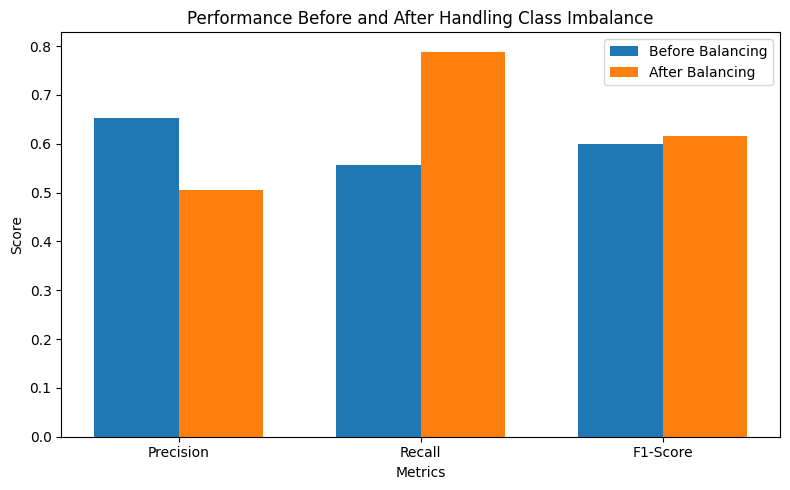

In [23]:
# Select the metrics we want to compare
metrics = ["Precision", "Recall", "F1-Score"]

before = [
    baseline_precision,
    baseline_recall,
    baseline_f1
]

after = [
    balanced_precision,
    balanced_recall,
    balanced_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, before, width, label="Before Balancing")
plt.bar(x + width/2, after, width, label="After Balancing")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Performance Before and After Handling Class Imbalance")
plt.xticks(x, metrics)
plt.legend()

plt.tight_layout()
plt.show()

## Step 10: Visualize Performance Comparison

The Precision, Recall, and F1-score of the baseline and class-weighted Logistic Regression models were visualized to show the effect of handling class imbalance.

The visualization highlights the substantial improvement in Recall after applying class weighting, while Precision decreased. The F1-score also improved slightly, showing a better balance between Precision and Recall.

## Step 11: Why Accuracy Can Be Misleading

Accuracy can be misleading when a dataset is imbalanced because it may give a high score even when the model performs poorly on the minority class. In this dataset, 73.46% of customers did not churn, while only 26.54% churned. A model could achieve relatively high accuracy by mainly predicting the majority class while missing many customers who actually churn. Therefore, Precision, Recall, and F1-score provide a more useful evaluation of the model's ability to identify churned customers.

In [24]:
print("Majority class percentage:",
      (df["Churn"].value_counts()["No"] / len(df)) * 100)

print("Minority class percentage:",
      (df["Churn"].value_counts()["Yes"] / len(df)) * 100)

Majority class percentage: 73.4630129206304
Minority class percentage: 26.536987079369588


## Step 12: Final Conclusion

In this task, the class imbalance in the Telco Customer Churn dataset was analyzed and addressed using class weighting. The dataset contained 73.46% non-churned customers and 26.54% churned customers, demonstrating a clear class imbalance.

The baseline Logistic Regression model achieved an accuracy of 80.34%, with a Recall of 55.61% and F1-score of 60.03%. After applying `class_weight="balanced"`, Recall increased significantly to 78.88% and F1-score improved to 61.59%, although Accuracy decreased to 73.88%.

These results demonstrate why accuracy alone can be misleading for imbalanced datasets. In this case, the balanced model was better at identifying customers who actually churned, making Recall and F1-score more informative metrics for evaluating the model.